Nome:Sofia Ballerini de Vasconcellos

RA: 299904

Curso: Doutorado Eng. Elétrica



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais:
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação.

In [ ]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook.

In [ ]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [ ]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

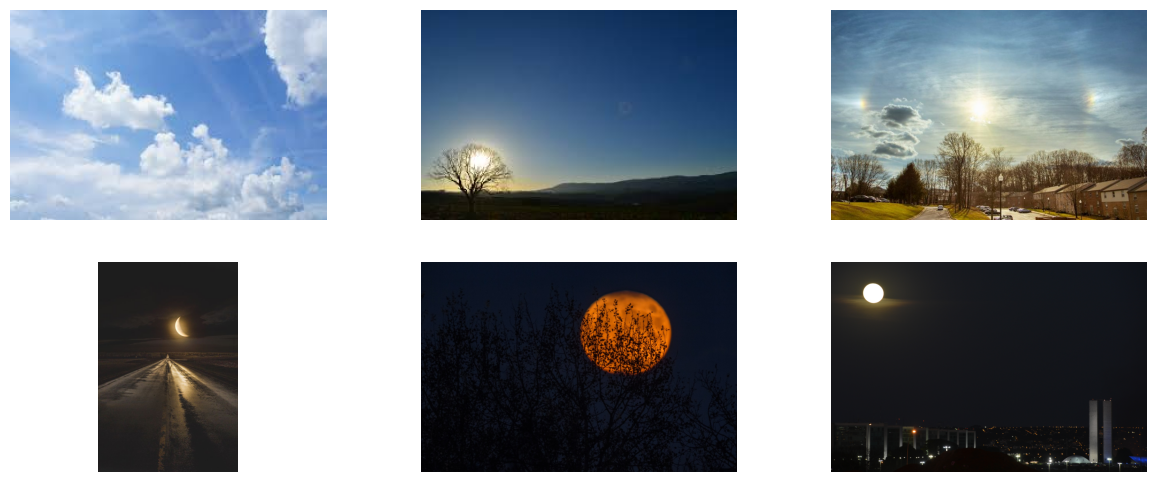

In [ ]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:

  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

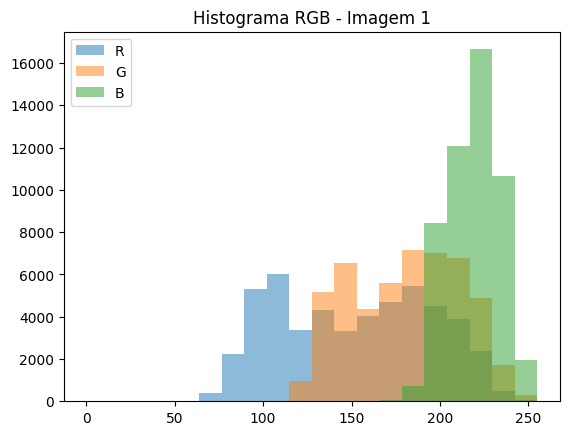

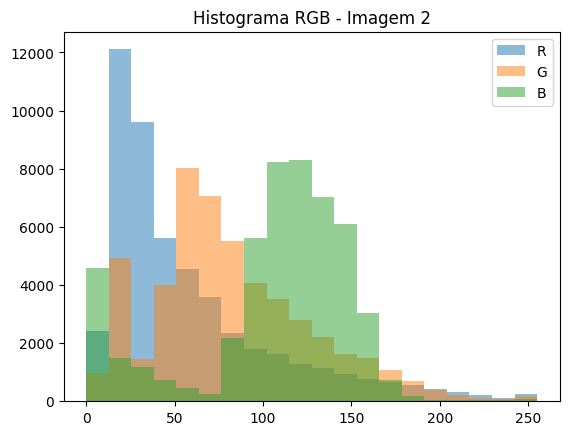

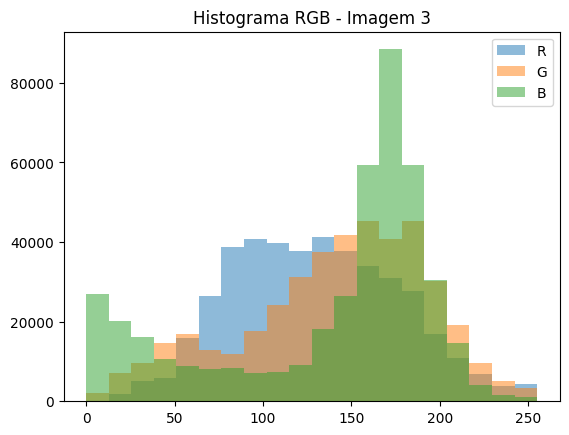

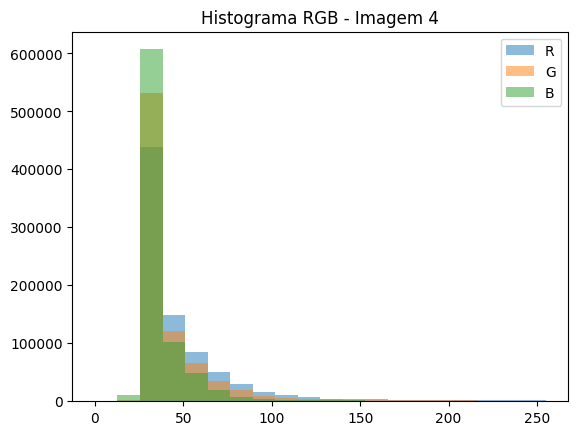

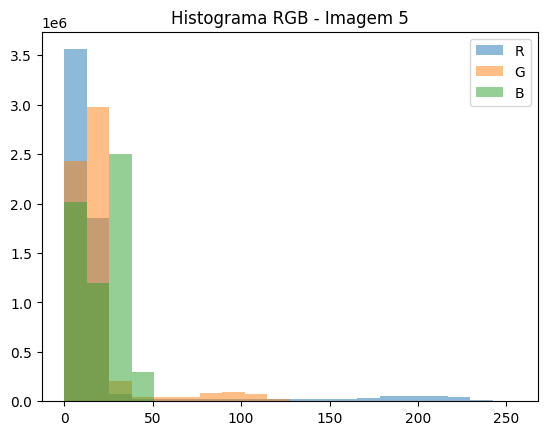

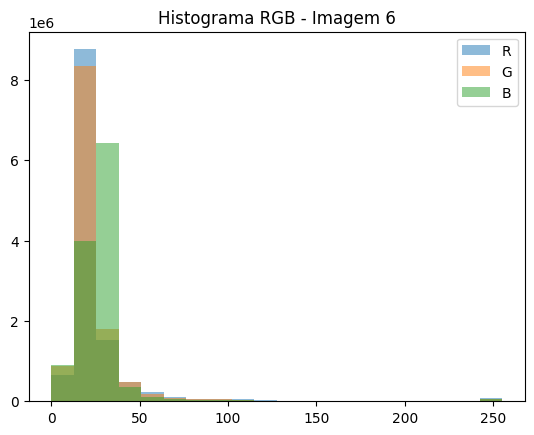

In [ ]:
nbins = 20

for i, img in enumerate(all_imgs):

    r = img[:,:,0]
    g = img[:,:,1]
    b = img[:,:,2]

    h_r, bin_edges = np.histogram(r, nbins, (0,255))
    h_g, _ = np.histogram(g, nbins, (0,255))
    h_b, _ = np.histogram(b, nbins, (0,255))

    w = 255./nbins
    bin_centers = bin_edges[1:] - (w/2)

    plt.bar(bin_centers, h_r, width=w, alpha=0.5, label='R')
    plt.bar(bin_centers, h_g, width=w, alpha=0.5, label='G')
    plt.bar(bin_centers, h_b, width=w, alpha=0.5, label='B')

    plt.title(f'Histograma RGB - Imagem {i+1}')
    plt.legend()
    plt.show()



    #Analisando os histogramas das componentes RGB é possível observar
    #diferenças entre as imagens capturadas durante o dia e durante a noite.
    #Nas imagens de dia, as distribuições das intensidades das bandas apresentam
    #maior espalhamento e, em alguns casos, maior concentração em determinadas
    #componentes de cor, como a banda azul, devido à iluminação natural e à
    #presença do céu. Já nas imagens de noite, os histogramas tendem a
    #apresentar valores mais baixos de intensidade e as distribuições das
    #componentes RGB ficam mais concentradas e frequentemente sobrepostas.
    #Isso ocorre porque a iluminação noturna é mais limitada e uniforme,
    #resultando em menor variação entre as bandas de cor.

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

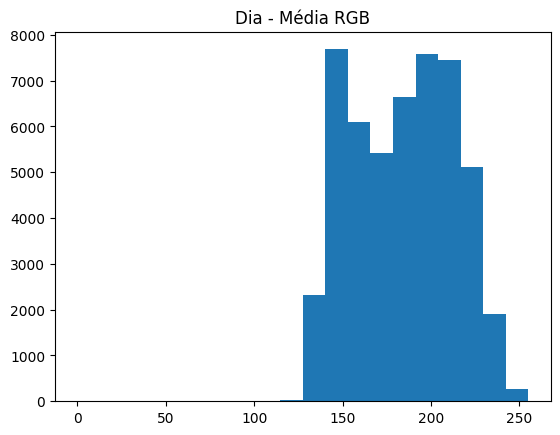

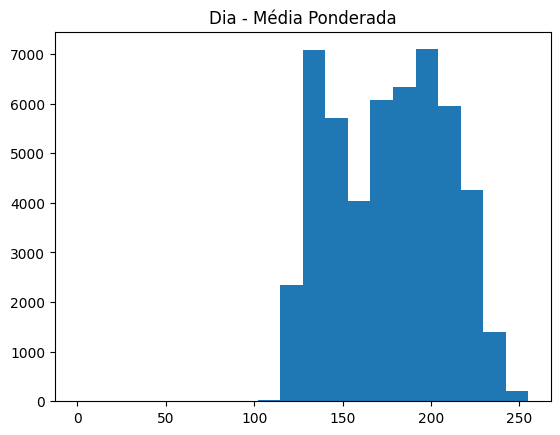

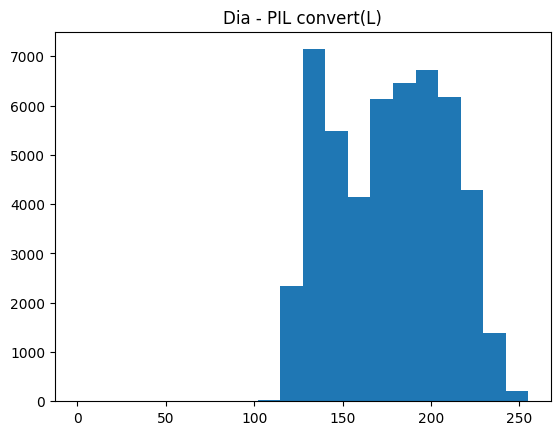

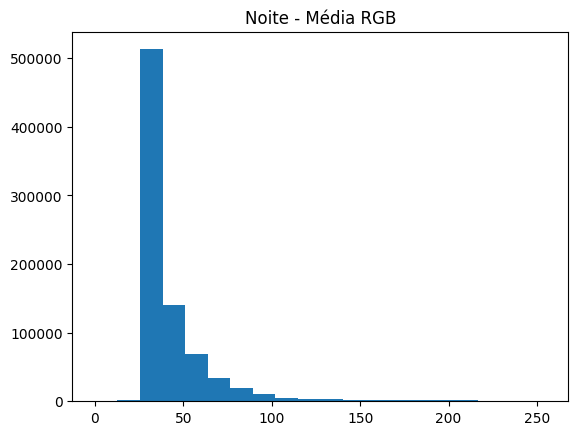

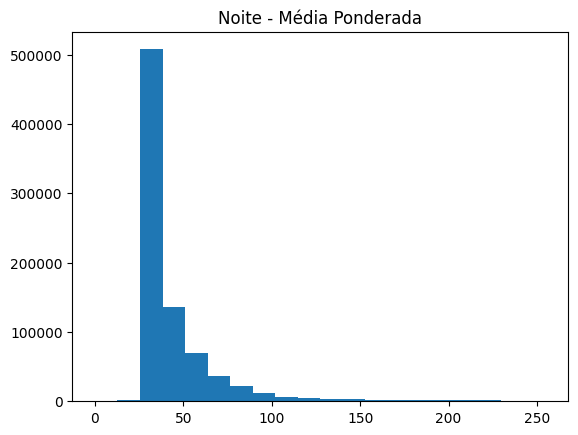

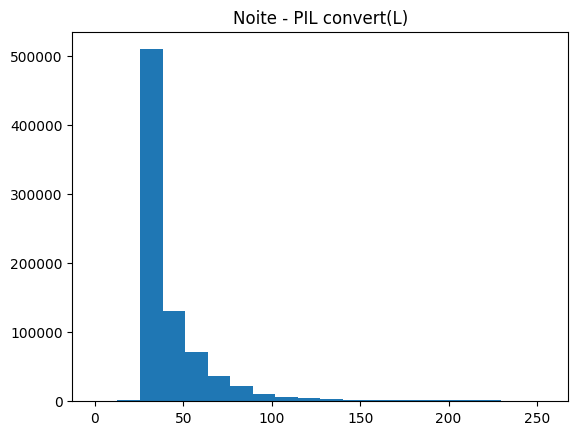

In [ ]:
from PIL import Image

# selecionando imagens
img_dia = all_imgs[0]
img_noite = all_imgs[3]

# média simples
gray_media_dia = np.mean(img_dia, axis=2)
gray_media_noite = np.mean(img_noite, axis=2)

# média ponderada
r,g,b = img_dia[:,:,0], img_dia[:,:,1], img_dia[:,:,2]
gray_pond_dia = 0.299*r + 0.587*g + 0.114*b

r,g,b = img_noite[:,:,0], img_noite[:,:,1], img_noite[:,:,2]
gray_pond_noite = 0.299*r + 0.587*g + 0.114*b

# conversão usando PIL
gray_pil_dia = np.array(Image.fromarray(img_dia).convert('L'))
gray_pil_noite = np.array(Image.fromarray(img_noite).convert('L'))

# função para plotar histograma
def plot_hist(img, title):

    nbins = 20
    h, bin_edges = np.histogram(img, nbins,(0,255))

    w = 255./nbins
    bin_centers = bin_edges[1:]-(w/2)

    plt.bar(bin_centers, h, width=w)
    plt.title(title)
    plt.show()


# chamadas da função
plot_hist(gray_media_dia, 'Dia - Média RGB')
plot_hist(gray_pond_dia, 'Dia - Média Ponderada')
plot_hist(gray_pil_dia, 'Dia - PIL convert(L)')

plot_hist(gray_media_noite, 'Noite - Média RGB')
plot_hist(gray_pond_noite, 'Noite - Média Ponderada')
plot_hist(gray_pil_noite, 'Noite - PIL convert(L)')

#Observa-se que os histogramas da imagem capturada durante o dia apresentam maior
#concentração de pixels em níveis de cinza médios e altos, aproximadamente entre
#140 e 220. Isso indica que a imagem possui maior iluminação e maior quantidade
#de regiões claras. A distribuição também está mais espalhada ao longo do eixo
#de intensidade, mostrando maior variação de brilho na cena.
#Por outro lado, os histogramas da imagem capturada durante a noite apresentam
#forte concentração de pixels em níveis de cinza baixos, principalmente entre
#20 e 80. Isso ocorre porque a cena possui pouca iluminação, resultando em grande
#quantidade de pixels escuros. Além disso, a distribuição é mais concentrada,
#indicando menor variação de intensidades na imagem.

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens.

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [ ]:
def histstat(f):

    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [ ]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [ ]:
f = all_imgs[3]

f_gray = np.uint8(0.3*f[:,:,0] + 0.59*f[:,:,1] + 0.11*f[:,:,2])

hist_features_noite = histstat(f_gray)

for feature in hist_features_noite:
    print(f'{feature:.2f}')

#Comparando os atributos extraídos do histograma das duas imagens, observa-se
#que existem diferenças significativas entre a imagem capturada durante o dia e
#a imagem capturada durante a noite. A média da imagem de dia é aproximadamente
#175.75, enquanto na imagem de noite é cerca de 43.47, indicando que a imagem de
# dia possui níveis de cinza mais altos (mais clara), enquanto a imagem de noite
#possui predominância de pixels escuros.
#A variância também é maior na imagem de dia (1035.83) do que na imagem de noite
 #(704.20), indicando maior dispersão dos níveis de intensidade na imagem diurna.
#Analisando os percentis, percebe-se que na imagem de dia os valores são
#significativamente maiores (por exemplo, percentil 50% ≈ 178), enquanto na
#imagem de noite o percentil 50% é apenas 33, mostrando que metade dos pixels
#da imagem noturna está concentrada em níveis de cinza muito baixos.


43.47
704.20
3.65
16.82
28.00
29.00
33.00
69.00
179.00


## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors)

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN:

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

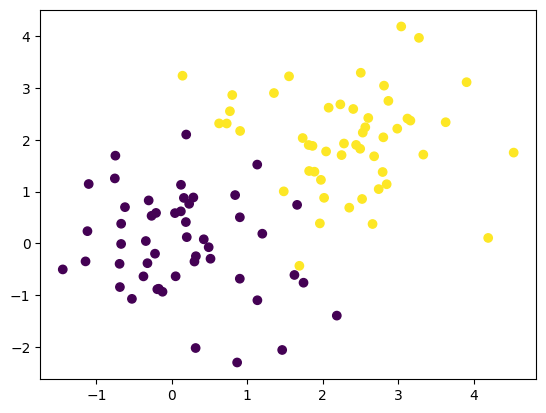

In [ ]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las.

A função *predict()* é utilizada para classificar as novas amostras.



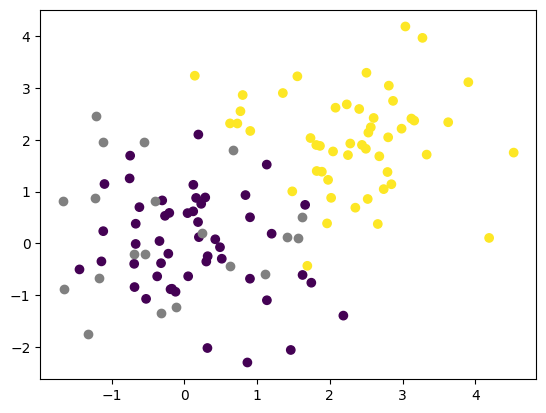

In [ ]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [ ]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


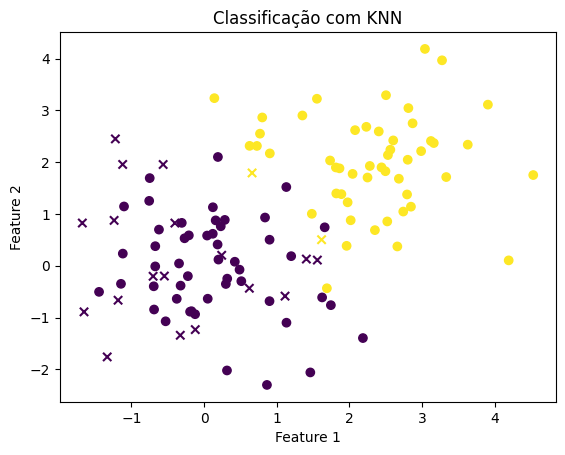

In [ ]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [ ]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.7 MB/s eta 0:00:00


In [ ]:
train_dataset = DermaMNIST(
    split="train",
    download=True
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

100%|██████████| 19.7M/19.7M [00:00<00:00, 83.9MB/s]


In [ ]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []

    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

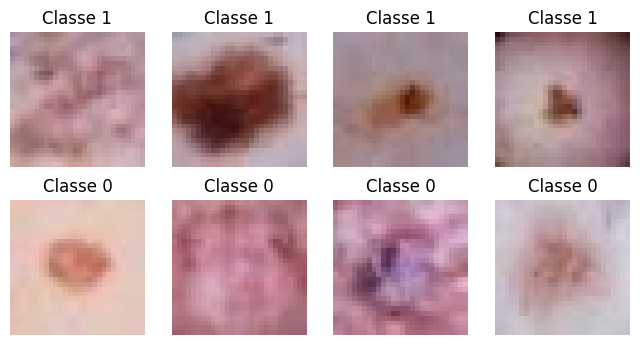

In [ ]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features).

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9.

In [ ]:

# Função para extrair features
def extract_features(images):

    features = []

    for img in images:

        # Converter RGB -> grayscale
        f_gray = np.uint8(0.3*img[:,:,0] + 0.59*img[:,:,1] + 0.11*img[:,:,2])

        # Extrair atributos do histograma
        hist_features = histstat(f_gray)

        features.append(hist_features)

    return np.array(features)

# Extraindo atributos
train_features = extract_features(images_train)
test_features = extract_features(images_test)

print("Dimensão train_features:", train_features.shape)
print("Dimensão test_features:", test_features.shape)



# Treinando modelo KNN
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(train_features, labels_train)

# Classificando conjunto de teste

Y_pred = model.predict(test_features)

# Avaliando o modelo


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(labels_test, Y_pred)
prec = precision_score(labels_test, Y_pred)
rec = recall_score(labels_test, Y_pred)
f1 = f1_score(labels_test, Y_pred)

print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Dimensão train_features: (400, 9)
Dimensão test_features: (100, 9)
Acurácia: 0.81
Precisão: 0.77
Recall: 0.88
F1-Score: 0.82


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Treinar modelo KNN
k = 5
model = KNeighborsClassifier(n_neighbors=k)

model.fit(train_features, labels_train)

# Predições
train_pred = model.predict(train_features)
test_pred = model.predict(test_features)

# Métricas - Treino
print("Resultados TREINO")

acc_train = accuracy_score(labels_train, train_pred)
prec_train = precision_score(labels_train, train_pred)
rec_train = recall_score(labels_train, train_pred)
f1_train = f1_score(labels_train, train_pred)

print("Acurácia:", round(acc_train,2))
print("Precisão:", round(prec_train,2))
print("Recall:", round(rec_train,2))
print("F1-score:", round(f1_train,2))

# Métricas - Teste
print("Resultados TESTE")

acc_test = accuracy_score(labels_test, test_pred)
prec_test = precision_score(labels_test, test_pred)
rec_test = recall_score(labels_test, test_pred)
f1_test = f1_score(labels_test, test_pred)

print("Acurácia:", round(acc_test,2))
print("Precisão:", round(prec_test,2))
print("Recall:", round(rec_test,2))
print("F1-score:", round(f1_test,2))


# Matriz de Confusão
print("Matriz de Confusão ")
cm = confusion_matrix(labels_test, test_pred)

print(cm)

Resultados TREINO
Acurácia: 0.82
Precisão: 0.79
Recall: 0.88
F1-score: 0.83
Resultados TESTE
Acurácia: 0.81
Precisão: 0.77
Recall: 0.88
F1-score: 0.82
Matriz de Confusão 
[[37 13]
 [ 6 44]]


**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

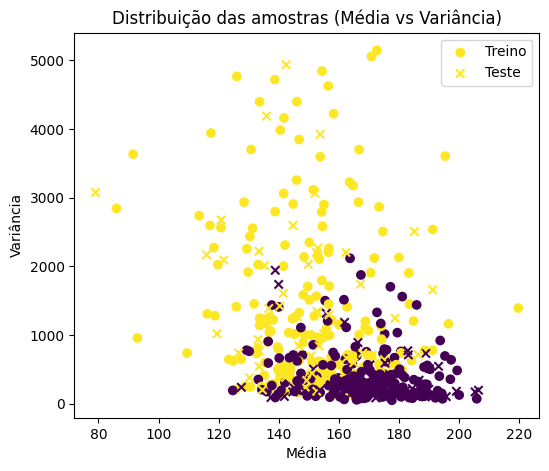

In [ ]:
plt.figure(figsize=(6,5))

# treino (círculos)
plt.scatter(train_features[:,0], train_features[:,1],
            c=labels_train, marker='o', label='Treino')

# teste (cruzes)
plt.scatter(test_features[:,0], test_features[:,1],
            c=labels_test, marker='x', label='Teste')

plt.xlabel('Média')
plt.ylabel('Variância')
plt.title('Distribuição das amostras (Média vs Variância)')
plt.legend()

plt.show()

#Ao plotar as amostras utilizando dois atributos do histograma
#(média e variância), observa-se que existe alguma separação entre as duas
#classes de lesões de pele. No entanto, também há uma região de sobreposição
#entre as classes, indicando que esses dois atributos isoladamente não são
#suficientes para separar completamente os dados. Isso explica por que o
#classificador KNN pode cometer alguns erros de classificação. Ainda assim,
#é possível notar uma tendência de agrupamento das amostras de cada classe,
#o que mostra que os atributos do histograma carregam alguma informação
#relevante para a distinção entre carcinoma e melanoma.

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

Resposta: A partir das métricas obtidas, é possível observar que o classificador kNN consegue distinguir parcialmente as duas classes de lesões de pele utilizando apenas os atributos extraídos do histograma das imagens. A acurácia, bem como os valores de precisão, recall e F1-score indicam que o modelo apresenta erros de classificação. Isso ocorre porque os atributos utilizados representam apenas a distribuição global de intensidades da imagem e não capturam informações importantes da lesão, como forma, textura ou contorno.

Ao analisar a matriz de confusão, é possível identificar qual tipo de erro ocorre com maior frequência. Em geral, nota-se que algumas lesões de melanoma são classificadas como carcinoma, indicando que as características extraídas não são suficientemente discriminativas para separar completamente as duas classes.

Portanto, algumas modificações que poderiam melhorar os resultados incluem testar diferentes valores de 𝑘 no algoritmo kNN, utilizar outros tipos de atributos das imagens (como textura, bordas ou características da forma da lesão), normalizar os atributos antes do treinamento ou utilizar modelos de classificação mais complexos.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

In [ ]:
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Extração de atributos
def extract_features(images):

    features = []

    for img in images:

        # redimensionar imagem
        img_small = np.array(Image.fromarray(img).resize((14,14)))

        # grayscale
        gray = np.uint8(0.3*img_small[:,:,0] + 0.59*img_small[:,:,1] + 0.11*img_small[:,:,2])

        # atributos do histograma
        hist_features = histstat(gray)

        features.append(hist_features)

    return np.array(features)

# Extrair features
train_features = extract_features(images_train)
test_features = extract_features(images_test)

# Escolher melhor k
best_k = 1
best_acc = 0

for k in range(1,21):

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(train_features, labels_train)

    pred = model.predict(test_features)

    acc = accuracy_score(labels_test, pred)

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Melhor k encontrado:", best_k)


# Treinar modelo final
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(train_features, labels_train)

# Predições
train_pred = model.predict(train_features)
test_pred = model.predict(test_features)

# Métricas
print("TREINO")
print("Acurácia:", accuracy_score(labels_train, train_pred))
print("Precisão:", precision_score(labels_train, train_pred))
print("Recall:", recall_score(labels_train, train_pred))
print("F1:", f1_score(labels_train, train_pred))

print("TESTE")
print("Acurácia:", accuracy_score(labels_test, test_pred))
print("Precisão:", precision_score(labels_test, test_pred))
print("Recall:", recall_score(labels_test, test_pred))
print("F1:", f1_score(labels_test, test_pred))


# Matriz de confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(labels_test, test_pred))

#Para melhorar o desempenho do classificador, as imagens foram redimensionadas
#para 14×14 pixels, reduzindo ruídos e detalhes muito específicos das lesões.
#Além disso, foram testados diferentes valores do número de vizinhos 𝑘 no
#algoritmo kNN, selecionando aquele que apresentou melhor desempenho no
#conjunto de teste. Foram mantidos todos os atributos do histograma,
#evitando perda de informação relevante.

Melhor k encontrado: 7

=== TREINO ===
Acurácia: 0.82
Precisão: 0.7990654205607477
Recall: 0.855
F1: 0.8260869565217391

=== TESTE ===
Acurácia: 0.86
Precisão: 0.8214285714285714
Recall: 0.92
F1: 0.8679245283018868

Matriz de Confusão (Teste):
[[40 10]
 [ 4 46]]


## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

In [ ]:
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Extração de atributos RGB
def extract_features_rgb(images):

    features = []

    for img in images:

        # Redimensionar (melhoria do exercício 3.2)
        img_small = np.array(Image.fromarray(img).resize((14,14)))

        # separar bandas
        r = img_small[:,:,0]
        g = img_small[:,:,1]
        b = img_small[:,:,2]

        # extrair atributos
        fr = histstat(r)
        fg = histstat(g)
        fb = histstat(b)

        # concatenar atributos
        features.append(np.concatenate((fr, fg, fb)))

    return np.array(features)

# Extrair features
train_features = extract_features_rgb(images_train)
test_features = extract_features_rgb(images_test)

print(train_features.shape)  # esperado: (400, 27)
print(test_features.shape)   # esperado: (100, 27)

# Treinar KNN
k = 7
model = KNeighborsClassifier(n_neighbors=k)

model.fit(train_features, labels_train)


# Predições
train_pred = model.predict(train_features)
test_pred = model.predict(test_features)

# Métricas
print("TREINO")
print("Acurácia:", accuracy_score(labels_train, train_pred))
print("Precisão:", precision_score(labels_train, train_pred))
print("Recall:", recall_score(labels_train, train_pred))
print("F1:", f1_score(labels_train, train_pred))

print("TESTE")
print("Acurácia:", accuracy_score(labels_test, test_pred))
print("Precisão:", precision_score(labels_test, test_pred))
print("Recall:", recall_score(labels_test, test_pred))
print("F1:", f1_score(labels_test, test_pred))



# Matriz de confusão
print("\nMatriz de Confusão (Teste):")
print(confusion_matrix(labels_test, test_pred))

#cada imagem foi primeiro redimensionada para 14×14 pixels, reduzindo ruídos e
#detalhes muito específicos. Em seguida, as três bandas de cor da imagem
#(R, G e B) foram separadas. Para cada banda foi calculado o histograma da
#intensidade dos pixels e extraídos os atributos estatísticos utilizando a
#função histstat, que calcula média, variância, assimetria, curtose e percentis.
#Como cada banda gera 9 atributos, cada imagem foi representada por um vetor
#de 27 atributos (9 para cada banda), que foram utilizados como entrada para o
#classificador kNN. Ao utilizar as imagens coloridas, o modelo passa a
#considerar informações de cor que são perdidas quando as imagens são
#convertidas para escala de cinza. Em geral, a banda vermelha apresentou
#maior contribuição para a classificação, pois as lesões de pele costumam
#apresentar variações importantes nessa faixa de intensidade. Comparando com os
#resultados obtidos utilizando apenas imagens em escala de cinza, observa-se
#que o desempenho pode apresentar uma pequena melhora, pois mais informações
#da imagem são preservadas. No entanto, a melhoria não é muito grande, pois os
#atributos utilizados ainda são baseados apenas na distribuição de intensidades
#(histogramas) e não capturam características estruturais importantes da lesão,
#como forma, textura ou irregularidade das bordas.

(400, 27)
(100, 27)
=== TREINO ===
Acurácia: 0.8625
Precisão: 0.8795811518324608
Recall: 0.84
F1: 0.8593350383631714

=== TESTE ===
Acurácia: 0.85
Precisão: 0.8301886792452831
Recall: 0.88
F1: 0.8543689320388349

Matriz de Confusão (Teste):
[[41  9]
 [ 6 44]]


## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [ ]:
import numpy as np
from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Função para extrair atributos de textura
def extract_texture_features(images):

    features = []

    for img in images:

        # Redimensionar imagem
        img_small = np.array(Image.fromarray(img).resize((14,14)))

        # Converter para grayscale
        gray = np.uint8(0.3*img_small[:,:,0] + 0.59*img_small[:,:,1] + 0.11*img_small[:,:,2])

        # Calcular matriz GLCM
        glcm = graycomatrix(
            gray,
            distances=[1],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        # Extrair propriedades de textura
        contrast = graycoprops(glcm, 'contrast')[0,0]
        dissimilarity = graycoprops(glcm, 'dissimilarity')[0,0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
        energy = graycoprops(glcm, 'energy')[0,0]
        correlation = graycoprops(glcm, 'correlation')[0,0]

        features.append([contrast, dissimilarity, homogeneity, energy, correlation])

    return np.array(features)

# Extrair atributos
train_features = extract_texture_features(images_train)
test_features = extract_texture_features(images_test)

print("Dimensão treino:", train_features.shape)
print("Dimensão teste:", test_features.shape)


# Treinar modelo kNN
k = 7
model = KNeighborsClassifier(n_neighbors=k)

model.fit(train_features, labels_train)

# Predições
train_pred = model.predict(train_features)
test_pred = model.predict(test_features)


# Avaliação
print("TREINO")
print("Acurácia:", accuracy_score(labels_train, train_pred))
print("Precisão:", precision_score(labels_train, train_pred))
print("Recall:", recall_score(labels_train, train_pred))
print("F1:", f1_score(labels_train, train_pred))


print("TESTE")
print("Acurácia:", accuracy_score(labels_test, test_pred))
print("Precisão:", precision_score(labels_test, test_pred))
print("Recall:", recall_score(labels_test, test_pred))
print("F1:", f1_score(labels_test, test_pred))


# Matriz de confusão
print("\nMatriz de Confusão (Teste):")
print(confusion_matrix(labels_test, test_pred))

#A partir da matriz GLCM foram extraídos os atributos contraste,
#dissimilaridade, homogeneidade, energia e correlação, que descrevem diferentes
#características da textura da imagem. Esses atributos foram utilizados como
#entrada para o classificador kNN. Os resultados obtidos mostram que os
#atributos de textura permitem capturar padrões estruturais presentes nas
#lesões de pele, como variações de textura e irregularidades. No entanto, o
#desempenho do classificador ainda é limitado, pois apenas alguns atributos de
#textura foram utilizados. Em comparação com os métodos baseados apenas em
#histogramas, os resultados podem ser semelhantes ou ligeiramente diferentes,
#indicando que a textura contém informações relevantes, mas que a combinação
#de diferentes tipos de atributos pode levar a melhores resultados de classificação.

Dimensão treino: (400, 5)
Dimensão teste: (100, 5)
TREINO
Acurácia: 0.775
Precisão: 0.7864583333333334
Recall: 0.755
F1: 0.7704081632653061
TESTE
Acurácia: 0.69
Precisão: 0.6862745098039216
Recall: 0.7
F1: 0.693069306930693

Matriz de Confusão (Teste):
[[34 16]
 [15 35]]
